# TimeGAN Pro: Realistic Candlestick Generation

This advanced notebook implements TimeGAN to generate **realistic candlestick** financial data.
Tailored for high-end GPUs (A100/H100) to maximize quality within a few hours.

In [1]:
# @title 1. Setup Environment (Installs mplfinance)
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn mplfinance

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import os

# Check GPU
print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found GPU: {gpus}")
    # Memory growth fix for some setups
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU found. Training will be slow.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.3 MB/s eta 0:00:00
TensorFlow: 2.19.0
Found GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# @title 2. Upload Data
from google.colab import files
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Uploaded: {filename}")

Saving train_sequences.csv to train_sequences.csv
Uploaded: train_sequences.csv


In [3]:
# @title 3. Robust Data Loading
def load_data(filename, seq_len=24):
    df = pd.read_csv(filename)
    # Cols: sequence_id, time_step, log_ret_open, log_ret_high, log_ret_low, log_ret_close
    feature_cols = df.columns[2:]
    print(f"Features: {list(feature_cols)}")

    # Try grouping
    data_list = []
    grouped = df.groupby('sequence_id')
    for _, group in grouped:
        if len(group) == seq_len:
            data_list.append(group[feature_cols].values)

    data_3d = np.array(data_list)
    print(f"Data Shape: {data_3d.shape} (Sequences, TimeSteps, Features)")
    return data_3d

real_data = load_data(filename)

Features: ['log_ret_open_norm', 'log_ret_high_norm', 'log_ret_low_norm', 'log_ret_close_norm']
Data Shape: (80468, 24, 4) (Sequences, TimeSteps, Features)


In [4]:
# @title 4. Advanced TimeGAN Model (with LeakyReLU & LayerNorm)

class TimeGAN:
    def __init__(self, seq_len, n_seq, hidden_dim=64, num_layers=3):
        self.seq_len = seq_len
        self.n_seq = n_seq
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedder = self.build_network('Embedder')
        self.recovery = self.build_network('Recovery')
        self.generator = self.build_network('Generator')
        self.supervisor = self.build_network('Supervisor')
        self.discriminator = self.build_network('Discriminator', output_dim=1, activation=None)

    def build_network(self, name, output_dim=None, activation='sigmoid'):
        if output_dim is None: output_dim = self.hidden_dim
        if name in ['Recovery', 'Generator']: output_dim = self.n_seq # match data dim

        model = tf.keras.Sequential(name=name)
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.n_seq if name in ['Embedder', 'Generator'] else self.hidden_dim)))

        for i in range(self.num_layers):
            model.add(tf.keras.layers.GRU(
                units=self.hidden_dim,
                return_sequences=True,
                activation='tanh', # GRU default is tanh, roughly stable
                # recurrent_dropout=0.2 # Can slow down cudnn
            ))
            model.add(tf.keras.layers.LayerNormalization()) # Stabilize training

        model.add(tf.keras.layers.Dense(output_dim, activation=activation))
        return model

In [5]:
# @title 5. Optimized Training Loop (A100 Ready)

def train_timegan_pro(data, iterations=10000, batch_size=256):
    no, seq_len, dim = data.shape
    timegan = TimeGAN(seq_len, dim, hidden_dim=64, num_layers=3)

    # Optimizers
    # Lower LR for stability, decay if possible
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3, decay_steps=1000, decay_rate=0.96)

    # Using one optimizer per network
    auto_opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    sup_opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    gen_opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    disc_opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    mse = tf.keras.losses.MeanSquaredError()
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def train_autoencoder_step(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            x_tilde = timegan.recovery(h)
            loss = 10 * tf.sqrt(mse(x, x_tilde))
        grads = tape.gradient(loss, timegan.embedder.trainable_variables + timegan.recovery.trainable_variables)
        auto_opt.apply_gradients(zip(grads, timegan.embedder.trainable_variables + timegan.recovery.trainable_variables))
        return loss

    @tf.function
    def train_supervisor_step(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat = timegan.supervisor(h)
            loss = mse(h[:,1:,:], h_hat[:,:-1,:])
        grads = tape.gradient(loss, timegan.supervisor.trainable_variables + timegan.generator.trainable_variables)
        sup_opt.apply_gradients(zip(grads, timegan.supervisor.trainable_variables + timegan.generator.trainable_variables))
        return loss

    @tf.function
    def train_joint_step(x, z):
        # Generator Step
        with tf.GradientTape() as tape_gen:
            h = timegan.embedder(x)
            # Supervised Loss
            h_hat_supervise = timegan.supervisor(h)
            loss_su = mse(h[:,1:,:], h_hat_supervise[:,:-1,:])

            # Unsupervised
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_fake = timegan.discriminator(h_hat)
            loss_gen = bce(tf.ones_like(y_fake), y_fake)

            # Momements (Mean/Var) Loss to prevent mode collapse (simple version)
            x_hat = timegan.recovery(h_hat)
            loss_moments = tf.reduce_mean(tf.abs(tf.reduce_mean(x_hat, 0) - tf.reduce_mean(x, 0))) + \
                           tf.reduce_mean(tf.abs(tf.math.reduce_std(x_hat, 0) - tf.math.reduce_std(x, 0)))

            total_g_loss = loss_su + loss_gen + 100 * tf.sqrt(loss_su) + 50 * loss_moments

        grads_gen = tape_gen.gradient(total_g_loss, timegan.generator.trainable_variables + timegan.supervisor.trainable_variables)
        gen_opt.apply_gradients(zip(grads_gen, timegan.generator.trainable_variables + timegan.supervisor.trainable_variables))

        # Embedder Step
        with tf.GradientTape() as tape_emb:
            h = timegan.embedder(x)
            h_hat = timegan.supervisor(h)
            x_tilde = timegan.recovery(h)
            loss_rec = 10 * tf.sqrt(mse(x, x_tilde))
            loss_su = mse(h[:,1:,:], h_hat[:,:-1,:])
            total_e_loss = loss_rec + 0.1 * loss_su
        grads_emb = tape_emb.gradient(total_e_loss, timegan.embedder.trainable_variables + timegan.recovery.trainable_variables)
        auto_opt.apply_gradients(zip(grads_emb, timegan.embedder.trainable_variables + timegan.recovery.trainable_variables))

        # Discriminator Step
        with tf.GradientTape() as tape_disc:
            h = timegan.embedder(x)
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_real = timegan.discriminator(h)
            y_fake = timegan.discriminator(h_hat)
            loss_d = bce(tf.ones_like(y_real), y_real) + bce(tf.zeros_like(y_fake), y_fake)
        grads_disc = tape_disc.gradient(loss_d, timegan.discriminator.trainable_variables)
        disc_opt.apply_gradients(zip(grads_disc, timegan.discriminator.trainable_variables))

        return total_g_loss, loss_d

    print("Phase 1: Autoencoder Training...")
    for i in range(iterations // 2):
        idx = np.random.randint(0, no, batch_size)
        train_autoencoder_step(tf.cast(data[idx], tf.float32))

    print("Phase 2: Supervisor Training...")
    for i in range(iterations // 2):
        idx = np.random.randint(0, no, batch_size)
        train_supervisor_step(tf.cast(data[idx], tf.float32))

    print("Phase 3: Joint Training (The Real Deal)...")
    for i in range(iterations):
        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], tf.float32)
        z_batch = tf.cast(np.random.normal(0, 1, (batch_size, seq_len, dim)), tf.float32)
        g_loss, d_loss = train_joint_step(x_batch, z_batch)

        if i % 500 == 0:
            print(f"Iter {i}: G_Loss={g_loss:.4f}, D_Loss={d_loss:.4f}")

    return timegan

# Set high iterations for A100
model = train_timegan_pro(real_data, iterations=10000, batch_size=256)

Phase 1: Autoencoder Training...
Phase 2: Supervisor Training...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Generator/gru_6/gru_cell/kernel', 'Generator/gru_6/gru_cell/recurrent_kernel', 'Generator/gru_6/gru_cell/bias', 'Generator/layer_normalization_6/gamma', 'Generator/layer_normalization_6/beta', 'Generator/gru_7/gru_cell/kernel', 'Generator/gru_7/gru_cell/recurrent_kernel', 'Generator/gru_7/gru_cell/bias', 'Generator/layer_normalization_7/gamma', 'Generator/layer_normalization_7/beta', 'Generator/gru_8/gru_cell/kernel', 'Generator/gru_8/gru_cell/recurrent_kernel', 'Generator/gru_8/gru_cell/bias', 'Generator/layer_normalization_8/gamma', 'Generator/layer_normalization_8/beta', 'Generator/dense_2/kernel', 'Generator/dense_2/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Phase 3: Joint Training (The Real Deal)...
Iter 0: G_Loss=28.8993, D_Loss=1.6002
Iter 500: G_Loss=18.6095, D_Loss=0.1108
Iter 1000: G_Loss=15.4818, D_Loss=1.4946
Iter 1500: G_Loss=16.1432, D_Loss=1.1521
Iter 2000: G_Loss=14.9642, D_Loss=0.4787
Iter 2500: G_Loss=14.6358, D_Loss=0.6288
Iter 3000: G_Loss=14.9675, D_Loss=0.3724
Iter 3500: G_Loss=14.1630, D_Loss=0.5582
Iter 4000: G_Loss=14.1761, D_Loss=0.8308
Iter 4500: G_Loss=13.6274, D_Loss=0.9064
Iter 5000: G_Loss=14.7531, D_Loss=0.9413
Iter 5500: G_Loss=12.7500, D_Loss=0.6842
Iter 6000: G_Loss=13.2051, D_Loss=0.4427
Iter 6500: G_Loss=12.7571, D_Loss=1.0874
Iter 7000: G_Loss=11.8622, D_Loss=0.5925
Iter 7500: G_Loss=14.3752, D_Loss=0.4791
Iter 8000: G_Loss=12.7521, D_Loss=0.9127
Iter 8500: G_Loss=10.7840, D_Loss=1.3392
Iter 9000: G_Loss=12.3775, D_Loss=0.6242
Iter 9500: G_Loss=11.8387, D_Loss=0.6041


/tmp/ipython-input-458472941.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_candle.index = pd.date_range(start='2024-01-01', periods=len(df_candle), freq='H')


Sample 1:


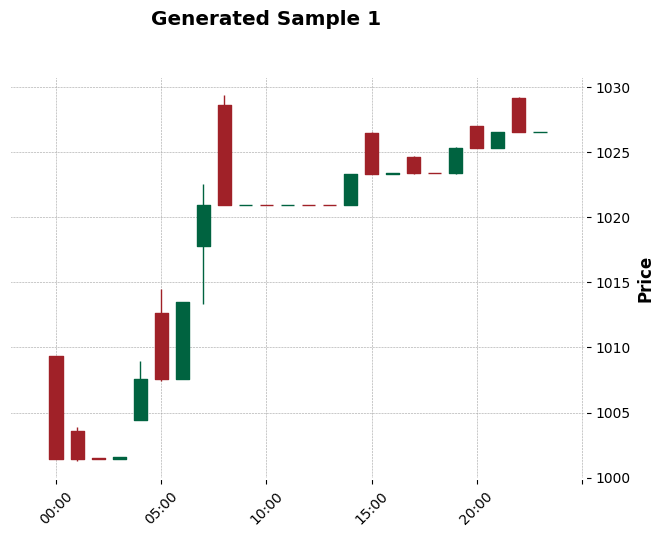

Sample 2:


/tmp/ipython-input-458472941.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_candle.index = pd.date_range(start='2024-01-01', periods=len(df_candle), freq='H')


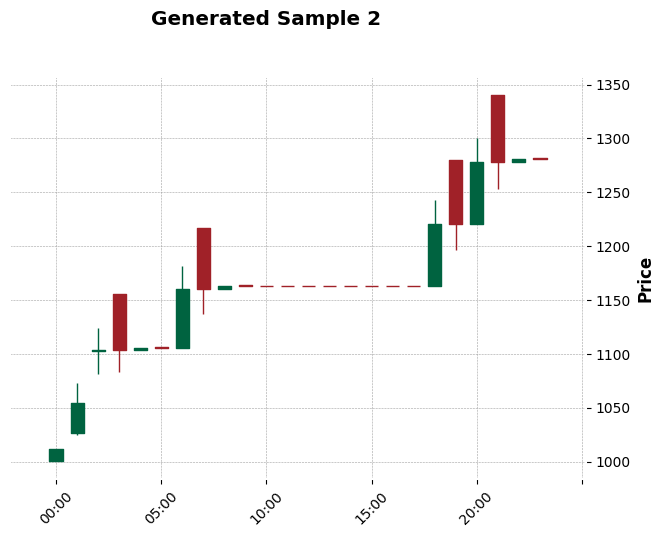

/tmp/ipython-input-458472941.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_candle.index = pd.date_range(start='2024-01-01', periods=len(df_candle), freq='H')


Sample 3:


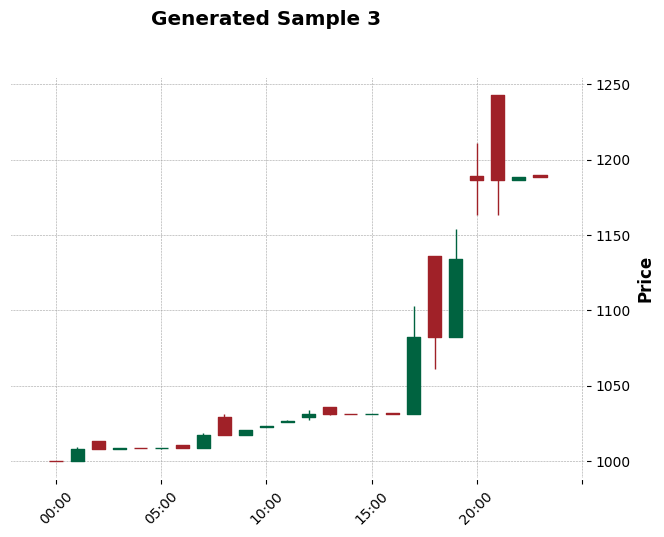

In [6]:
# @title 6. Generate & Visualize Candles

def reconstruct_ohlc(normalized_seq, initial_price=1000):
    """
    Converts normalized log returns back to a price path.
    Assumption: columns are [Open_ret, High_ret, Low_ret, Close_ret]
    OR [Open, High, Low, Close] relative to PREVIOUS CLOSE.

    This function forces H >= O, C >= L consistency.
    """
    # De-normalize: assuming data was scaled to [-1, 1], we map it back to specific movement range
    # If data is purely log returns, we just use it.
    # Let's interpret 'normalized' value X as a percentage change of X%

    prices = []
    current_close = initial_price

    # Only taking the 'close' return to build the trend, then building candles around it
    # Col order assumption: 0:Open, 1:High, 2:Low, 3:Close

    for step in normalized_seq:
        # Scale factor: generated values might be small or large.
        # We'll treat them as % changes. E.g. 0.1 means 10% move (huge) or 0.1% move?
        # Let's assume standard volatility (e.g. multiplied by 0.01)

        ro, rh, rl, rc = step

        # Synthesize candles based on previous close
        open_p = current_close * (1 + ro * 0.05)
        close_p = current_close * (1 + rc * 0.05)
        high_p = max(open_p, close_p) * (1 + abs(rh) * 0.02)
        low_p = min(open_p, close_p) * (1 - abs(rl) * 0.02)

        # Update state
        prices.append([open_p, high_p, low_p, close_p])
        current_close = close_p

    return pd.DataFrame(prices, columns=['Open', 'High', 'Low', 'Close'])

# Generate samples
test_size = 100
z = np.random.normal(0, 1, (test_size, 24, real_data.shape[2]))
generated_seqs = model.recovery(model.supervisor(model.generator(z))).numpy()

# Visualize 3 random samples
for i in range(3):
    idx = np.random.randint(0, test_size)
    seq = generated_seqs[idx]
    df_candle = reconstruct_ohlc(seq)

    # Create a dummy index for mplfinance
    df_candle.index = pd.date_range(start='2024-01-01', periods=len(df_candle), freq='H')

    print(f"Sample {i+1}:")
    mpf.plot(df_candle, type='candle', style='charles', volume=False, title=f'Generated Sample {i+1}')